# ⚡ Extension J — Functional Group Fingerprinting & Chemical Class Profiling
## *What makes anti-malarials different from natural products — at the functional-group level?*

**Prerequisites:** Complete Parts A–G of `caismd_2026_chemspace_xplr.ipynb` first, or run all cells here independently (this notebook is self-contained).

**Datasets used:**
- `../data/malaria_box_afrodb_combined.csv` — MMV Malaria Box (400) + AfroDb (903)
- `../data/pubchem_aid2302_2k.csv` — PubChem AID 2302 (2 000 compounds, Active/Inactive)

---

### Learning Objectives
By the end of this notebook you will be able to:
1. Interpret MACCS key frequency profiles and explain which structural features distinguish synthetic anti-malarials from natural products
2. Use Ertl functional group counts and a χ² enrichment test to identify pharmacophore features associated with anti-malarial activity
3. Overlay functional group presence onto a UMAP and interpret cluster vs scatter patterns
4. Compute and compare five library diversity metrics: mean NN-Tanimoto, NN distance distribution, scaffold diversity ratio, singleton scaffold fraction, and Ro5 compliance
5. Apply Butina sphere-exclusion clustering and test whether structural clusters align with activity labels
6. Explain why MACCS keys and ECFP4 fingerprints produce different UMAP layouts and when each is preferable

---

### What you will do

| Section | Topic | Tool | Time |
|---|---|---|---|
| **J1** | MACCS keys: which structural features separate MMV vs AfroDb? | RDKit MACCSkeys | ~8 min |
| **J2** | Ertl functional groups: Active vs Inactive SAR + χ² enrichment | RDKit Fragments | ~12 min |
| **J3** | UMAP panels coloured by functional group presence | umap-learn | ~10 min |
| **J5** | Five library diversity metrics + distance distribution histogram | RDKit + numpy | ~10 min |
| **J4** | Butina scaffold clustering + activity enrichment test | RDKit Butina | ~12 min |
| **J6** | MACCS keys vs ECFP4: does fingerprint choice change the map? | umap-learn | ~12 min |

**Logical flow:**  
J1–J2 answer *"what is structurally different?"* at the feature level.  
J3 shows *"where do those features sit in chemical space?"*  
J5 quantifies *"how diverse are the libraries?"* — the quantitative foundation.  
J4 groups compounds into clusters to test whether structural similarity predicts activity.  
J6 tests whether conclusions hold across fingerprint representations.

---

### Datasets at a glance

| Dataset | File | Used in | Activity labels |
|---|---|---|---|
| MMV Malaria Box + AfroDb | `malaria_box_afrodb_combined.csv` | J1, J5 | **No activity split** — MMV compounds are all confirmed anti-malarial hits; AfroDb are African natural products. Comparison is MMV vs AfroDb (source label). |
| PubChem AID 2302 | `pubchem_aid2302_2k.csv` | J2, J3, J4, J6 | **Binary screen labels** — Active (≥ 50% *P. falciparum* Dd2 growth inhibition at 2 µM) vs Inactive (< 50%). No pIC50 values. |

> ⚠️ The MMV Malaria Box contains **only active** compounds (all confirmed hits, EC₅₀ < 5 µM).  
> It is **not used** for Active/Inactive SAR analysis. For that we use the independent  
> PubChem AID 2302 dataset, which is a proper single-point screen with both active and inactive compounds.


In [1]:
# ============================================================
# CELL J0 — Imports & Constants
# PRE-WRITTEN: run this cell first
# ============================================================
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from scipy.stats import chi2_contingency

from rdkit import Chem, DataStructs
from rdkit.Chem import MACCSkeys, AllChem, Fragments
from rdkit.Chem import Descriptors, rdMolDescriptors
import inspect

# Make src/ importable
_nb_dir  = os.path.abspath(os.getcwd())
_src_dir = os.path.join(_nb_dir, "..", "src")
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

# ── Constants (mirror main notebook) ────────────────────────
RANDOM_SEED = 42
FP_RADIUS   = 2
FP_NBITS    = 2048

# ── Colour palettes ─────────────────────────────────────────
PALETTE = {
    'MMV'    : '#2196F3',   # blue
    'AfroDb' : '#4CAF50',   # green
}
# Activity palette — used in J2/J3 with PubChem AID 2302 data
ACTIVITY_PALETTE = {
    'Active'   : '#E53935',   # red   — ≥50% P. falciparum Dd2 inhibition at 2 µM
    'Inactive' : '#1565C0',   # blue  — <50% inhibition
}

# ── Data paths ───────────────────────────────────────────────
# J1: Malaria Box (MMV) + AfroDb natural products
DATA_PATH_COMBINED  = "../data/malaria_box_afrodb_combined.csv"
# J2/J3: PubChem AID 2302 — GSK P. falciparum Dd2 whole-cell assay (2 000 compounds)
DATA_PATH_PUBCHEM   = "../data/pubchem_aid2302_2k.csv"

print("✅ Imports ready.")
print(f"   J1 dataset : {DATA_PATH_COMBINED}")
print(f"   J2/J3 data : {DATA_PATH_PUBCHEM}")


✅ Imports ready.
   J1 dataset : ../data/malaria_box_afrodb_combined.csv
   J2/J3 data : ../data/pubchem_aid2302_2k.csv


In [2]:
# ============================================================
# CELL J0b — Load Both Datasets
# PRE-WRITTEN: run this cell
# ============================================================
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# ── Dataset 1: MMV Malaria Box + AfroDb  (used in J1) ───────
df_combined = pd.read_csv(DATA_PATH_COMBINED)
df_combined['mol'] = df_combined['SMILES'].apply(Chem.MolFromSmiles)
n_ok_combined = df_combined['mol'].notna().sum()
print(f"[J1]  MMV + AfroDb : {n_ok_combined} / {len(df_combined)} molecules parsed")
print(f"      Sources: {df_combined['source'].value_counts().to_dict()}")

# ── Dataset 2: PubChem AID 2302 (used in J2 & J3) ───────────
df_pubchem = pd.read_csv(DATA_PATH_PUBCHEM)
df_pubchem['mol'] = df_pubchem['SMILES'].apply(Chem.MolFromSmiles)
n_ok_pc = df_pubchem['mol'].notna().sum()
print(f"\n[J2/J3]  PubChem AID 2302 : {n_ok_pc} / {len(df_pubchem)} molecules parsed")
print(f"         Activity: {df_pubchem['activity'].value_counts().to_dict()}")
print()
print("Assay details — PubChem AID 2302:")
print("  Title    : Inhibition of P. falciparum Dd2")
print("  Source   : GlaxoSmithKline (GSK)")
print("  Protocol : Whole-cell LDH assay, 2 µM single-point screen")
print("  Active   : ≥ 50% growth inhibition → IC₅₀ < 2 µM")
print("  Inactive : < 50% inhibition at 2 µM")
print("  Sample   : 2 000 compounds (59% Active / 41% Inactive, mirrors assay ratio)")

RDLogger.EnableLog('rdApp.*')


[J1]  MMV + AfroDb : 1303 / 1303 molecules parsed
      Sources: {'AfroDb': 903, 'MMV': 400}



[J2/J3]  PubChem AID 2302 : 2000 / 2000 molecules parsed


         Activity: {'Active': 1184, 'Inactive': 816}

Assay details — PubChem AID 2302:
  Title    : Inhibition of P. falciparum Dd2
  Source   : GlaxoSmithKline (GSK)
  Protocol : Whole-cell LDH assay, 2 µM single-point screen
  Active   : ≥ 50% growth inhibition → IC₅₀ < 2 µM
  Inactive : < 50% inhibition at 2 µM
  Sample   : 2 000 compounds (59% Active / 41% Inactive, mirrors assay ratio)


---
## Part J1 — MACCS Keys: What Structural Features Distinguish Anti-Malarials from Natural Products? ⏱ *~8 min*

> 📌 **MACCS keys** are 167 predefined structural keys, each corresponding to a named SMARTS pattern (e.g., key 160 = aromatic amine, key 148 = ether, key 166 = ring).  
> Unlike Morgan fingerprints (hashed, anonymous bits), MACCS keys are **interpretable by design**.

**What we do here:**
1. Compute MACCS keys for every molecule
2. Calculate the **frequency** of each key being set (= 1) per source group (MMV vs AfroDb)
3. Plot a **diverging bar chart** of the top enriched keys in each direction
4. Interpret the chemistry behind the most discriminating keys

> ⚠️ RDKit MACCS keys are 167 bits but stored as 168-element vectors (bit 0 is unused). Use indices 1–167.


In [3]:
# ============================================================
# CELL J1a — Compute MACCS Keys for All Molecules
# PRE-WRITTEN: just run this cell
# ============================================================

df_j1 = df_combined[df_combined['mol'].notna()].copy().reset_index(drop=True)

# Compute MACCS keys → 167-bit numpy array per molecule (drop bit 0, unused)
def mol_to_maccs(mol):
    """Return MACCS keys as a numpy uint8 array of length 167 (bits 1–167)."""
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros(168, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr[1:]   # drop bit 0

maccs_matrix = np.vstack([mol_to_maccs(m) for m in tqdm(df_j1['mol'], desc='MACCS keys')])
print(f"MACCS matrix shape: {maccs_matrix.shape}  (N_molecules × 167 bits)")

# Store in dataframe for easy grouping
maccs_cols = [f'MACCS_{i}' for i in range(1, len(maccs_matrix[0]) + 1)]  # length = actual array size
df_maccs   = pd.DataFrame(maccs_matrix, columns=maccs_cols)
df_maccs['source'] = df_j1['source'].values

# Key frequency (= fraction of molecules where bit is set) per source
freq_mmv   = df_maccs[df_maccs['source'] == 'MMV'][maccs_cols].mean()
freq_afro  = df_maccs[df_maccs['source'] == 'AfroDb'][maccs_cols].mean()

freq_diff  = freq_mmv - freq_afro   # positive = enriched in MMV
print(f"\nTop 5 bits enriched in MMV    : {freq_diff.nlargest(5).index.tolist()}")
print(f"Top 5 bits enriched in AfroDb : {freq_diff.nsmallest(5).index.tolist()}")



MACCS keys:   0%|          | 0/1303 [00:00<?, ?it/s]


MACCS keys:  12%|█▏        | 150/1303 [00:00<00:00, 1496.32it/s]


MACCS keys:  23%|██▎       | 300/1303 [00:00<00:00, 1475.79it/s]


MACCS keys:  34%|███▍      | 448/1303 [00:00<00:00, 1251.04it/s]


MACCS keys:  44%|████▍     | 577/1303 [00:00<00:00, 1105.69it/s]

...


MACCS keys:  77%|███████▋  | 1003/1303 [00:00<00:00, 922.02it/s]


MACCS keys:  85%|████████▌ | 1108/1303 [00:01<00:00, 955.09it/s]


MACCS keys:  94%|█████████▍| 1224/1303 [00:01<00:00, 1011.11it/s]


MACCS keys: 100%|██████████| 1303/1303 [00:01<00:00, 1042.62it/s]

MACCS matrix shape: (1303, 166)  (N_molecules × 167 bits)

Top 5 bits enriched in MMV    : ['MACCS_161', 'MACCS_158', 'MACCS_142', 'MACCS_156', 'MACCS_121']
Top 5 bits enriched in AfroDb : ['MACCS_140', 'MACCS_89', 'MACCS_146', 'MACCS_139', 'MACCS_99']


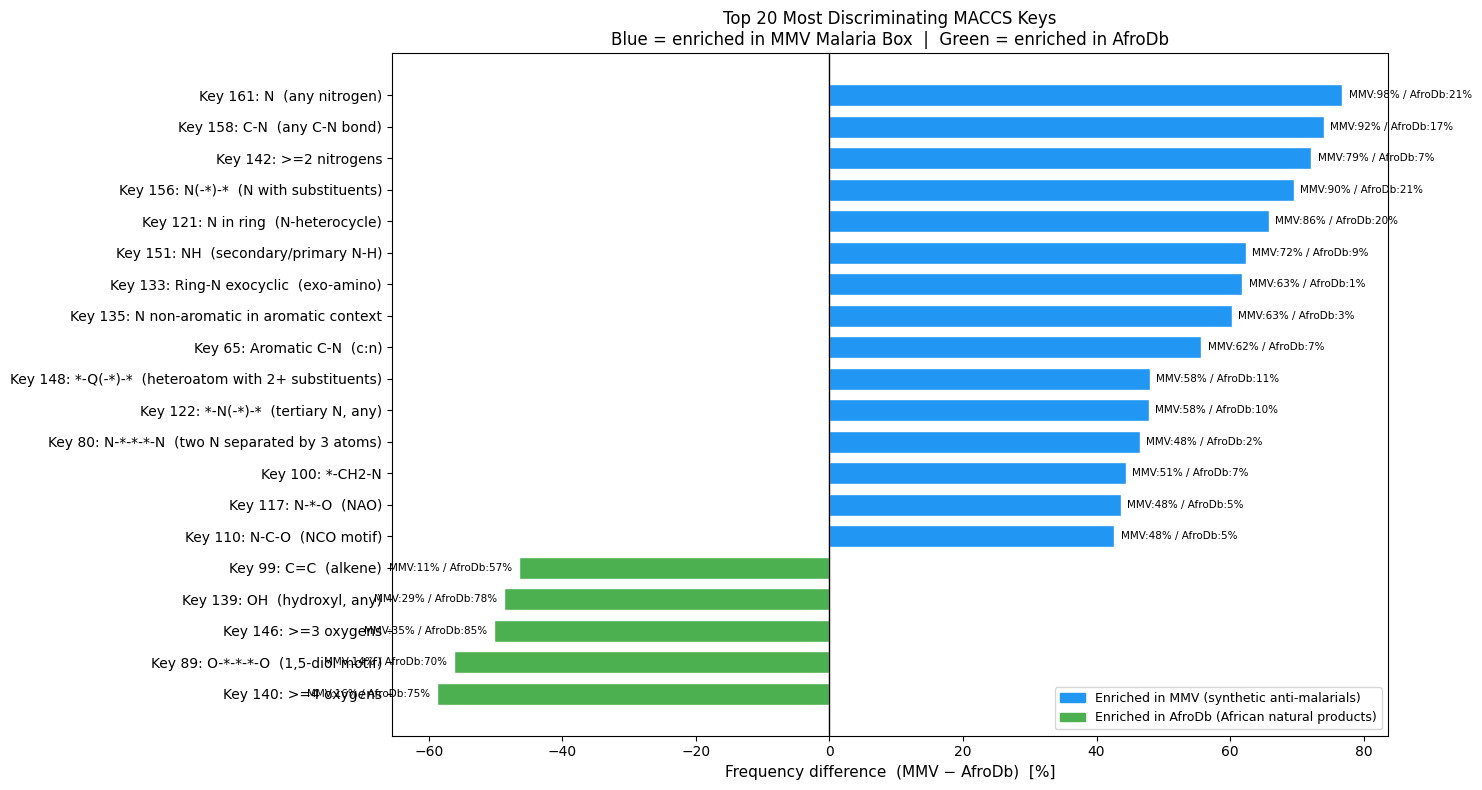


💡 Reading the chart:
   Blue bars (right)  → feature is MORE common in MMV synthetic anti-malarials
   Green bars (left)  → feature is MORE common in AfroDb African natural products
   Width              → magnitude of the frequency difference (%)


In [4]:
# ============================================================
# CELL J1b — MACCS Key Labels & Diverging Bar Chart
# PRE-WRITTEN: run this cell — focus on reading the chart
# ============================================================

# Human-readable labels for MACCS keys 1–167.
# Stored in src/maccs_labels.py to keep this cell compact.
from maccs_labels import MACCS_LABELS

# Select top-N most discriminating bits (by |diff|) for the chart
N_TOP = 20
top_idx = freq_diff.abs().nlargest(N_TOP).index
plot_df = pd.DataFrame({
    'bit'      : top_idx,
    'diff'     : freq_diff[top_idx].values,
    'freq_mmv' : freq_mmv[top_idx].values,
    'freq_afro': freq_afro[top_idx].values,
})
plot_df = plot_df.sort_values('diff', ascending=True)

# Human label: "Key 162: Aromatic atom" etc.
def bit_label(col_name):
    bit_num = int(col_name.split('_')[1])
    desc = MACCS_LABELS.get(bit_num, f'Key {bit_num}')
    return f"Key {bit_num}: {desc}"

plot_df['label'] = plot_df['bit'].apply(bit_label)

fig, ax = plt.subplots(figsize=(13, 8))
colours = ['#4CAF50' if d < 0 else '#2196F3' for d in plot_df['diff']]
ax.barh(plot_df['label'], plot_df['diff'] * 100, color=colours, edgecolor='white', height=0.7)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Frequency difference  (MMV − AfroDb)  [%]', fontsize=11)
ax.set_title(f'Top {N_TOP} Most Discriminating MACCS Keys\n'
             f'Blue = enriched in MMV Malaria Box  |  Green = enriched in AfroDb', fontsize=12)

mmv_patch  = mpatches.Patch(color='#2196F3', label='Enriched in MMV (synthetic anti-malarials)')
afro_patch = mpatches.Patch(color='#4CAF50', label='Enriched in AfroDb (African natural products)')
ax.legend(handles=[mmv_patch, afro_patch], fontsize=9, loc='lower right')

# Annotate bars with absolute frequencies.
# Labels are placed INSIDE each bar (near its tip) to avoid overlapping
# with the y-axis tick labels on the left side.
INSET = 1.5   # pp inset from bar tip
for y_pos, (_, row) in enumerate(plot_df.iterrows()):
    x   = row['diff'] * 100
    txt = f"MMV:{row['freq_mmv']*100:.0f}% / AfroDb:{row['freq_afro']*100:.0f}%"
    if x >= 0:
        # Blue bar (right): label inside, right-aligned near the tip
        ax.text(x - INSET, y_pos, txt, va='center', ha='right', fontsize=7, color='white', fontweight='bold')
    else:
        # Green bar (left): label inside, left-aligned near the tip
        ax.text(x + INSET, y_pos, txt, va='center', ha='left',  fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(left=0.28)   # room for y-axis tick labels
plt.show()

print()
print("💡 Reading the chart:")
print("   Blue bars (right)  → feature is MORE common in MMV synthetic anti-malarials")
print("   Green bars (left)  → feature is MORE common in AfroDb African natural products")
print("   Width              → magnitude of the frequency difference (%)")


### 💬 Stop & Discuss — J1

> *"Look at the blue bars (features enriched in MMV synthetic anti-malarials):*  
> *1. Which feature is the single biggest differentiator? Does this surprise you?*  
> *2. Natural products are often described as 'more complex' — do the green bars support this? What structural features make them different?*  
> *3. If you found a new AfroDb compound that had the top MMV-enriched MACCS keys, what would you prioritise doing with it?"*

---

**⚡ EXTENSION J1-EXT** *(optional — ~5 min)*
```python
# Instead of top-20 by |diff|, use a chi-squared test to identify
# STATISTICALLY significant differences (accounting for sample size).
# Hint: use scipy.stats.chi2_contingency on a 2×2 contingency table
# for each MACCS bit (bit_set vs not_set) × (MMV vs AfroDb).
# Apply Bonferroni correction for 167 tests.
```


### 🔬 Method note — Frequency difference (J1) vs χ² enrichment test (J2)

You may have noticed that J1 and J2 use **different methods** to identify enriched features. This is deliberate.

| | J1 — Frequency difference | J2 — χ² enrichment test |
|---|---|---|
| **What it computes** | `freq_MMV − freq_AfroDb` per MACCS bit | χ² statistic + p-value + odds ratio per Ertl fragment |
| **Output** | A signed percentage difference | A p-value, an odds ratio, and a significance flag |
| **Accounts for sample size?** | ❌ No — a 5% difference looks the same regardless of N | ✅ Yes — a 5% difference is only flagged if N is large enough |
| **Multiple testing correction?** | ❌ No | ✅ Yes (Bonferroni) |
| **Interpretability** | Very intuitive: "Key 162 is set in 80% of MMV but only 30% of AfroDb" | Richer: direction (OR) + confidence (p) + effect size (χ²) |
| **When to use it** | **Exploratory visualisation** — you want to *see* what differs and by how much | **Hypothesis testing** — you want to *claim* that a fragment is a genuine pharmacophore signal |

**In short:**  
Use the frequency difference when **exploring** and you want a quick visual overview.  
Use the χ² test when **reporting** which features are statistically associated with activity, especially when testing many features simultaneously.

> The J1 chart would show a large bar for a fragment even if the dataset were tiny and the result unreliable. The J2 test would not flag it as significant in that case. Both views are useful — they answer different questions.

---
## Part J2 — Ertl Functional Groups: Active vs Inactive Anti-Malarials ⏱ *~12 min*

> 📌 **Ertl functional groups** (`rdkit.Chem.Fragments`) are 85 named fragment counters, each backed by an explicit SMARTS pattern. Unlike MACCS keys (structural environment), they target **pharmacophore-relevant functional groups**: amides, halogens, pyridines, phenols, lactams, etc.

**What we do:**
1. Compute all 85 Ertl fragment counts per molecule
2. Convert counts → binary presence (0/1) for interpretability
3. Calculate hit rates per group: **Active vs Inactive vs AfroDb**
4. Plot a heatmap of hit rates
5. **TODO J2**: fill in the fragment computation loop + activity threshold + χ² test

> ⚠️ **Activity labels (PubChem AID 2302):**  
> **Active** = ≥ 50% growth inhibition of *P. falciparum* Dd2 at 2 µM (n = 1 184)  
> **Inactive** = < 50% inhibition at 2 µM (n = 816)  
> This is a binary single-point screen — there are no pIC50 values in this dataset.


In [5]:
# ============================================================
# CELL J2a — Ertl Fragment Functions (PRE-WRITTEN reference)
# PRE-WRITTEN: just run this cell
# ============================================================

# Collect all 85 Ertl fragment functions from rdkit.Chem.Fragments
ERTL_FNS = {
    name: fn
    for name, fn in inspect.getmembers(Fragments)
    if callable(fn) and not name.startswith('_')
}
ERTL_NAMES = sorted(ERTL_FNS.keys())

print(f"Total Ertl fragment functions: {len(ERTL_NAMES)}")
print()
print("First 20:")
for n in ERTL_NAMES[:20]:
    print(f"  {n}")
print("  ...")

# Human-readable short labels for selected fragments
# (used for axis tick labels in the heatmap)
ERTL_SHORT = {
    'fr_Al_OH'      : 'Aliphatic OH',
    'fr_Ar_OH'      : 'Aromatic OH (phenol)',
    'fr_Ar_N'       : 'Aromatic N',
    'fr_Ar_NH'      : 'Aromatic NH',
    'fr_amide'      : 'Amide',
    'fr_aniline'    : 'Aniline (Ar-NH₂)',
    'fr_benzene'    : 'Benzene ring',
    'fr_ester'      : 'Ester',
    'fr_ether'      : 'Ether',
    'fr_halogen'    : 'Halogen',
    'fr_imidazole'  : 'Imidazole',
    'fr_ketone'     : 'Ketone',
    'fr_lactam'     : 'Lactam',
    'fr_methoxy'    : 'Methoxy',
    'fr_morpholine' : 'Morpholine',
    'fr_NH0'        : 'Tertiary amine',
    'fr_NH1'        : 'Secondary amine',
    'fr_NH2'        : 'Primary amine',
    'fr_nitrile'    : 'Nitrile',
    'fr_nitro'      : 'Nitro',
    'fr_phenol'     : 'Phenol',
    'fr_piperdine'  : 'Piperidine',
    'fr_piperzine'  : 'Piperazine',
    'fr_pyridine'   : 'Pyridine',
    'fr_sulfide'    : 'Sulfide',
    'fr_sulfonamd'  : 'Sulfonamide',
    'fr_thiazole'   : 'Thiazole',
    'fr_thiophene'  : 'Thiophene',
    'fr_urea'       : 'Urea',
}

def ertl_label(name):
    return ERTL_SHORT.get(name, name.replace('fr_', '').replace('_', ' '))


Total Ertl fragment functions: 85

First 20:
  fr_Al_COO
  fr_Al_OH
  fr_Al_OH_noTert
  fr_ArN
  fr_Ar_COO
  fr_Ar_N
  fr_Ar_NH
  fr_Ar_OH
  fr_COO
  fr_COO2
  fr_C_O
  fr_C_O_noCOO
  fr_C_S
  fr_HOCCN
  fr_Imine
  fr_NH0
  fr_NH1
  fr_NH2
  fr_N_O
  fr_Ndealkylation1
  ...


In [ ]:
# ============================================================
# CELL J2b — Compute Ertl Fragment Matrix
# TODO J2-A  +  pre-written scaffolding
# ============================================================

# --- PRE-WRITTEN scaffold ---
def compute_ertl_row(mol):
    """
    Compute all 85 Ertl fragment counts for one molecule.
    Returns a dict  {fragment_name: count}.
    Counts are integers (≥ 0); a count > 0 means the group is present.
    """
    if mol is None:
        return {name: 0 for name in ERTL_NAMES}
    return {name: ERTL_FNS[name](mol) for name in ERTL_NAMES}

# Work with the PubChem AID 2302 dataset (J2 & J3)
df_j2 = df_pubchem[df_pubchem['mol'].notna()].copy().reset_index(drop=True)

# ============================================================
# TODO J2-A — Apply compute_ertl_row() to every molecule in df_j2.
# Store the result as a DataFrame called df_ertl
# (rows = molecules, columns = ERTL_NAMES).
# Add 'activity' column from df_j2.
# ============================================================

rows     = [compute_ertl_row(mol) for mol in tqdm(df_j2['___'], desc='Ertl fragments')]
df_ertl  = pd.DataFrame(rows, columns=ERTL_NAMES)
df_ertl['activity'] = df_j2['___'].values

print(f"Ertl matrix shape: {df_ertl[ERTL_NAMES].shape}")
print()

# Convert counts → binary presence (1 = present, 0 = absent)
ertl_binary = (df_ertl[ERTL_NAMES] > 0).astype(int)
df_ertl[ERTL_NAMES] = ertl_binary

print("Fragment presence rates (by group):")
groups = ['Active', 'Inactive']
for grp in groups:
    mask = df_ertl['activity'] == grp
    n    = mask.sum()
    rates = ertl_binary[mask].mean()
    print(f"  {grp:10s} (n={n:4d}): top fragment = {rates.idxmax()} ({rates.max():.0%})")


In [ ]:
# ============================================================
# CELL J2c — χ² Enrichment Test + Hit-Rate Heatmap
# TODO J2-B  +  pre-written heatmap
# ============================================================

# ── TODO J2-B — χ² Enrichment Test ────────────────────────
#
# A chi-squared (χ²) test of independence checks whether the
# presence of a functional group is statistically associated
# with activity, or whether any observed difference could be
# due to chance.
#
# For each Ertl fragment we build a 2×2 contingency table:
#
#              | fragment present | fragment absent
#   Active     |        a         |        b
#   Inactive   |        c         |        d
#
# The χ² statistic measures how far the observed cell counts
# deviate from the counts we'd expect if activity and fragment
# presence were independent:
#
#   χ² = Σ (observed − expected)² / expected
#
# A large χ² (small p-value) means the fragment is enriched
# (or depleted) in one activity class beyond what chance predicts.
# We use Yates' continuity correction (correction=True) because
# some cell counts are small.
#
# Reference: Pearson (1900) Philos. Mag. 50:157
#   https://doi.org/10.1080/14786440009463897
#
# ── Bonferroni correction ───────────────────────────────────
# We test 85 fragments simultaneously. Running 85 tests at
# α = 0.05 gives ~4 false positives by chance (85 × 0.05 = 4.25).
# The Bonferroni correction controls the family-wise error rate
# by dividing α by the number of tests:
#
#   α_Bonferroni = 0.05 / 85 ≈ 0.000588
#
# A fragment is called significant only if p < α_Bonferroni.
# This is conservative but simple and widely used in SAR screening.
# Reference: Bonferroni (1936) Pubbl. Ist. Super. Sci. Econ. Comm. 8:3–62
#
# Store results in a DataFrame `enrichment` with columns:
#   fragment, chi2, p_value, p_bonferroni, significant, odds_ratio

mask_active   = df_ertl['activity'] == 'Active'
mask_inactive = df_ertl['activity'] == 'Inactive'
ALPHA         = 0.05
ALPHA_BONF    = ___ / len(ERTL_NAMES)   # TODO: fill in ALPHA

results = []
for frag in ERTL_NAMES:
    a = df_ertl.loc[mask_active,   frag].sum()
    b = mask_active.sum()   - a
    c = df_ertl.loc[mask_inactive, frag].sum()
    d = mask_inactive.sum() - c

    table = [[a, b], [c, d]]
    try:
        chi2, p, _, _ = chi2_contingency(table, correction=True)
    except ValueError:
        chi2, p = 0.0, 1.0

    # Odds ratio (add 0.5 smoothing to avoid div-by-zero)
    or_val = ((a + 0.5) / (b + 0.5)) / ((c + 0.5) / (d + 0.5))

    results.append({
        'fragment'     : frag,
        'chi2'         : chi2,
        'p_value'      : p,
        'p_bonferroni' : p * len(ERTL_NAMES),
        'significant'  : p < ALPHA_BONF,
        'odds_ratio'   : or_val,
    })

enrichment = pd.DataFrame(results).sort_values('p_value')
n_sig = enrichment['significant'].sum()
print(f"Fragments significantly enriched (Bonferroni α={ALPHA_BONF:.4f}): {n_sig}")
print()
print(enrichment[enrichment['significant']][['fragment','chi2','p_bonferroni','odds_ratio']].to_string())


### 📖 Reading the Enrichment Table

The table above has four columns. Here is how to interpret each one.

| Column | What it measures | How to read it |
|---|---|---|
| `chi2` | Strength of the association | Larger = stronger signal. A χ² of 25 on 1 df is highly significant; a χ² of 1 is noise. |
| `p_bonferroni` | Corrected p-value | Probability of seeing this association by chance across all 85 tests. Significant if < 0.05 (after Bonferroni). |
| `odds_ratio` | Direction and magnitude of enrichment | **OR > 1** → fragment more common in **Actives**. **OR < 1** → more common in **Inactives**. OR = 1 → no association. |

**Example interpretation:**

- OR = 2.2 for `fr_Al_OH` → aliphatic –OH is **2.2× more likely** in an Active than an Inactive compound.
- OR = 0.48 for `fr_unbrch_alkane` → unbranched alkyl chains are **∼2× more likely in Inactives** (1 / 0.48 ≈ 2.1).
- OR = 4.7 for `fr_N_O` → N–O bond compounds are **∼5× more likely in Actives** — the strongest signal.

> ⚠️ **Correlation ≠ causation.** A significant fragment co-occurs with activity more than expected but does not necessarily *cause* it. Fragments are often correlated with each other, so a significant hit may be a proxy for another feature.

In [ ]:
# ============================================================
# CELL J2d — Hit-Rate Heatmap: Active vs Inactive vs AfroDb
# PRE-WRITTEN: just run this cell
# ============================================================

groups = ['Active', 'Inactive']

# Compute hit-rate (fraction of group where fragment is present) per group
hit_rates = {}
group_sizes = {}
for grp in groups:
    mask = df_ertl['activity'] == grp
    group_sizes[grp] = mask.sum()
    hit_rates[grp]   = df_ertl.loc[mask, ERTL_NAMES].mean()

hit_df = pd.DataFrame(hit_rates)   # shape: (85 fragments × 3 groups)

# Select fragments to display:
# (a) fragments that appear in ≥5% of at least one group (filter noise)
# (b) then sort by max hit rate descending
min_rate = 0.05
keep = hit_df.max(axis=1) >= min_rate
hit_df_plot = hit_df[keep].sort_values('Active', ascending=False)

# Human-readable row labels
hit_df_plot.index = [ertl_label(n) for n in hit_df_plot.index]

# Rename columns to include group sizes
hit_df_plot.columns = [f"{g}\n(n={group_sizes[g]})" for g in groups]

fig, ax = plt.subplots(figsize=(7, max(6, len(hit_df_plot) * 0.32)))

sns.heatmap(
    hit_df_plot * 100,
    ax        = ax,
    cmap      = 'YlOrRd',
    annot     = True,
    fmt       = '.0f',
    linewidths= 0.4,
    linecolor = 'white',
    cbar_kws  = {'label': 'Fragment presence rate (%)'},
    vmin      = 0,
    vmax      = 100,
)

ax.set_title('Ertl Functional Group Hit Rates\nActive vs Inactive — PubChem AID 2302 (P. falciparum Dd2, n=2 000)',
             fontsize=11, pad=12)
ax.set_xlabel('Group', fontsize=10)
ax.set_ylabel('Ertl Fragment', fontsize=10)
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=9)

# Mark statistically significant fragments (from J2c) with *
sig_frags = set(enrichment[enrichment['significant']]['fragment'].tolist())
for tick in ax.get_yticklabels():
    raw_name = [k for k, v in {**ERTL_SHORT, **{n: n.replace('fr_','').replace('_',' ') for n in ERTL_NAMES}}.items()
                if v == tick.get_text() or k.replace('fr_','').replace('_',' ') == tick.get_text()]
    frag_name = f"fr_{tick.get_text().replace(' ','_')}"
    if any(s in sig_frags for s in [frag_name] + raw_name):
        tick.set_text(tick.get_text() + ' *')
        tick.set_fontweight('bold')
ax.set_yticklabels(ax.get_yticklabels())

plt.tight_layout()
plt.show()

print()
print("* = statistically significant enrichment (χ², Bonferroni corrected, α=0.05)")
print()
print("💡 Read across each row:")
print("   Large difference between Active and Inactive columns → potential pharmacophore feature")
print("   Fragments consistently high across both groups       → likely ubiquitous scaffolds (low specificity)")


### 💬 Stop & Discuss — J2

> *"Study the heatmap — each row is a functional group, each column is a chemical set:*  
> *1. Which functional group shows the biggest Active vs Inactive difference? What might that suggest about the anti-malarial pharmacophore?*  
> *2. Are there functional groups present in AfroDb natural products at rates similar to the Active MMV set? These compounds are **structural bridges** — why might they be interesting?*  
> *3. What are the limitations of this analysis? (Hint: sample size, selection bias in the MMV library, correlation between features...)*"

---

## Part J3 — UMAP Re-Coloured by Functional Group Presence ⏱ *~6 min*

> 📌 We re-use the UMAP coordinates computed in Part G of the main notebook.  
> Here we overlay a **binary colour** (present/absent) for 4 selected functional groups.  
> The goal: visualise **where** in chemical space each feature lives.  
> Do halogenated compounds cluster? Where do phenols sit relative to AID 2302 active compounds?

> ⚠️ **To run this section standalone**, the UMAP must be recomputed below.  
> If you already ran Part G, import `df_clean` directly instead.


In [ ]:
# ============================================================
# CELL J3a — Compute UMAP on PubChem AID 2302 (standalone-safe)
# PRE-WRITTEN: just run this cell
# ============================================================
import umap as umap_lib

print("Computing Morgan fingerprints for UMAP (PubChem AID 2302)...")

def mol_to_fp(mol, radius=FP_RADIUS, nbits=FP_NBITS):
    """
    Compute a Morgan (ECFP-style) fingerprint as a numpy boolean array.
    Uses the new MorganGenerator API (RDKit >= 2022).
    """
    from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
    gen = GetMorganGenerator(radius=radius, fpSize=nbits)
    fp  = gen.GetFingerprintAsNumPy(mol)
    return fp.astype(np.uint8)

fp_matrix = np.vstack([mol_to_fp(m) for m in tqdm(df_j2['mol'], desc='Morgan FP')])

print("Running UMAP (jaccard metric, ~30–60 s)...")
reducer = umap_lib.UMAP(
    n_neighbors  = 15,
    min_dist     = 0.1,
    metric       = 'jaccard',
    n_components = 2,
    random_state = RANDOM_SEED,
)
umap_coords = reducer.fit_transform(fp_matrix)

df_j2 = df_j2.copy()
df_j2['UMAP_1'] = umap_coords[:, 0]
df_j2['UMAP_2'] = umap_coords[:, 1]

# Copy Ertl binary columns into df_j2 for the J3 panels
for col in ERTL_NAMES:
    df_j2[col] = df_ertl[col].values

print(f"✅ UMAP done. Embedding shape: {umap_coords.shape}")
print(f"   Active  : {(df_j2['activity']=='Active').sum()} compounds")
print(f"   Inactive: {(df_j2['activity']=='Inactive').sum()} compounds")


In [ ]:
# ============================================================
# CELL J3b — UMAP Panels: 4 Functional Groups
# PRE-WRITTEN panel loop + TODO J3 for choosing your own fragment
# ============================================================

# --- PRE-WRITTEN: four fragments to visualise ---
PANEL_FRAGMENTS = [
    ('fr_halogen',   'Halogen (F/Cl/Br/I)'),
    ('fr_Ar_OH',     'Aromatic OH (phenol)'),
    ('fr_pyridine',  'Pyridine'),
    # ============================================================
    # TODO J3 — Choose a 4th fragment from ERTL_NAMES to visualise.
    # Replace the ___ below with a fragment name, e.g. 'fr_amide',
    # 'fr_NH2', 'fr_ether', 'fr_benzene', etc.
    # ============================================================
    ('fr____',       'Your choice — fill in name and label'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (frag_col, frag_label) in zip(axes, PANEL_FRAGMENTS):

    if frag_col.endswith('___') or frag_col not in df_j2.columns:
        ax.text(0.5, 0.5, 'TODO J3 — fill in\nyour fragment name',
                ha='center', va='center', fontsize=13, color='grey',
                transform=ax.transAxes)
        ax.set_title(frag_label, fontsize=10)
        ax.axis('off')
        continue

    present = df_j2[frag_col] == 1
    absent  = df_j2[frag_col] == 0

    ax.scatter(df_j2.loc[absent, 'UMAP_1'], df_j2.loc[absent, 'UMAP_2'],
               c='#E0E0E0', s=12, alpha=0.5, edgecolors='none', zorder=1,
               label=f'Absent ({absent.sum()})')

    for act_label, colour in ACTIVITY_PALETTE.items():
        mask = present & (df_j2['activity'] == act_label)
        ax.scatter(df_j2.loc[mask, 'UMAP_1'], df_j2.loc[mask, 'UMAP_2'],
                   c=colour, s=28, alpha=0.85, edgecolors='none', zorder=2,
                   label=f'{act_label} with feature ({mask.sum()})')

    pct_active   = df_j2[df_j2['activity']=='Active'][frag_col].mean() * 100
    pct_inactive = df_j2[df_j2['activity']=='Inactive'][frag_col].mean() * 100
    ax.set_title(f'{frag_label}\nActive: {pct_active:.0f}%  |  Inactive: {pct_inactive:.0f}%', fontsize=9.5)
    ax.set_xlabel('UMAP 1', fontsize=8)
    ax.set_ylabel('UMAP 2', fontsize=8)
    ax.legend(fontsize=7.5, loc='lower right', framealpha=0.7)

plt.suptitle('UMAP Chemical Space — PubChem AID 2302 P. falciparum Dd2\n'
             'Coloured = fragment present (Red = Active · Blue = Inactive)  |  Grey = absent',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 💬 Stop & Discuss — J3

> *"For each of the four UMAP panels:*  
> *1. Is the functional group **clustered** or **scattered** across chemical space? What does each pattern tell you?*  
> *2. For your chosen fragment (TODO J3): did the distribution match your expectation? Why or why not?*  
> *3. Which AfroDb compounds appear to occupy the same UMAP region as active MMV compounds **and** share a key functional group? These are your top screening candidates.*"



---
## ⚡ Extension J5 — Library Diversity Metrics: Comparing MMV vs AfroDb

*~8 min · Requires: `maccs_matrix` from J1a and `df_j1` (MMV + AfroDb combined dataset)*

> 📌 A UMAP gives an intuitive feel for diversity, but **not a number**. These five metrics give us quantities we can compare and cite:

| Metric | What it measures |
|---|---|
| Mean nearest-neighbour Tanimoto | Redundancy — higher = more crowded |
| NN-Tanimoto distribution | Shape of the similarity landscape |
| Scaffold diversity ratio | Unique Murcko scaffolds / N |
| Singleton scaffold fraction | Fraction of truly unique scaffolds |
| Ro5 compliance rate | Drug-likeness of the library |

Higher mean NN-Tanimoto → more redundancy. Lower → more diverse.


In [ ]:
# ============================================================
# EXTENSION J5 — Library Diversity Metrics
# PRE-WRITTEN scaffold + TODO J5
# ============================================================
from rdkit.Chem.Scaffolds import MurckoScaffold

# ── Rebuild MACCS-based RDKit fps for both groups ───────────
# (maccs_matrix is already computed from J1a as numpy rows)
def maccs_row_to_bv(arr):
    """Convert 167-element numpy uint8 array → RDKit ExplicitBitVect."""
    from rdkit.DataStructs import ExplicitBitVect
    bv = ExplicitBitVect(167)
    for i, v in enumerate(arr):
        if v:
            bv.SetBit(i)
    return bv

fps_all = [maccs_row_to_bv(maccs_matrix[i]) for i in range(len(maccs_matrix))]
fps_mmv   = [fps_all[i] for i in range(len(df_j1)) if df_j1.iloc[i]['source'] == 'MMV']
fps_afro  = [fps_all[i] for i in range(len(df_j1)) if df_j1.iloc[i]['source'] == 'AfroDb']
df_mmv_j1 = df_j1[df_j1['source'] == 'MMV'].reset_index(drop=True)
df_afro_j1= df_j1[df_j1['source'] == 'AfroDb'].reset_index(drop=True)

# ── Metric 1: Mean nearest-neighbour Tanimoto ───────────────
def mean_nn_tanimoto(fps):
    """
    For each fingerprint, find the highest Tanimoto similarity
    to any OTHER fingerprint in the set (nearest neighbour).
    Return the mean across all compounds.
    """
    nn_sims = []
    for i, fp in enumerate(fps):
        sims = DataStructs.BulkTanimotoSimilarity(fp, fps)
        sims[i] = 0.0          # exclude self-similarity
        nn_sims.append(max(sims))
    return np.mean(nn_sims)

print("Computing mean NN-Tanimoto (MACCS keys)…")
nn_mmv  = mean_nn_tanimoto(fps_mmv)
nn_afro = mean_nn_tanimoto(fps_afro)
print(f"  MMV Malaria Box : {nn_mmv:.3f}")
print(f"  AfroDb NPs      : {nn_afro:.3f}")

# ── Metric 2: Scaffold diversity ratio ──────────────────────
def get_murcko_smiles(mol):
    try:
        sc  = MurckoScaffold.GetScaffoldForMol(mol)
        smi = Chem.MolToSmiles(sc)
        return smi if smi else 'no_scaffold'
    except:
        return 'no_scaffold'

# ============================================================
# TODO J5-A — Compute the scaffold diversity ratio for MMV and AfroDb.
# 1. Apply get_murcko_smiles() to each mol in df_mmv_j1 and df_afro_j1.
# 2. Count unique scaffolds / total compounds.
# Store results as scaffold_ratio_mmv and scaffold_ratio_afro.
# ============================================================
scaffolds_mmv  = df_mmv_j1['mol'].apply(___)                   # TODO J5-A
scaffolds_afro = df_afro_j1['mol'].apply(___)                  # TODO J5-A

scaffold_ratio_mmv  = scaffolds_mmv.nunique()  / len(scaffolds_mmv)
scaffold_ratio_afro = scaffolds_afro.nunique() / len(scaffolds_afro)
print(f"\nScaffold diversity ratio (unique scaffolds / N):")
print(f"  MMV Malaria Box : {scaffold_ratio_mmv:.3f}  ({scaffolds_mmv.nunique()} unique / {len(scaffolds_mmv)})")
print(f"  AfroDb NPs      : {scaffold_ratio_afro:.3f}  ({scaffolds_afro.nunique()} unique / {len(scaffolds_afro)})")

# ── Metric 3: Ro5 compliance rate ───────────────────────────
def compute_ro5(mol):
    """Return True if molecule passes all 4 Lipinski rules."""
    if mol is None:
        return np.nan
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    return (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)

# ============================================================
# TODO J5-B — Compute Ro5 compliance rate for each library.
# Apply compute_ro5() to the 'mol' column of df_mmv_j1 and df_afro_j1.
# Compute the fraction of True values (dropna first).
# ============================================================
ro5_mmv  = df_mmv_j1['mol'].apply(compute_ro5).dropna().mean()
ro5_afro = df_afro_j1['mol'].apply(___).dropna().mean()            # TODO J5-B

print(f"\nRo5 compliance rate (fraction passing all 4 rules):")
print(f"  MMV Malaria Box : {ro5_mmv:.1%}")
print(f"  AfroDb NPs      : {ro5_afro:.1%}")

# --- PRE-WRITTEN: Summary comparison bar chart ---
metrics = {
    'Mean NN-Tanimoto\n(MACCS, lower = more diverse)' : (nn_mmv, nn_afro),
    'Scaffold diversity\nratio (higher = more diverse)': (scaffold_ratio_mmv, scaffold_ratio_afro),
    'Ro5 compliance\nrate (fraction)'                  : (ro5_mmv, ro5_afro),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (metric_name, (val_mmv, val_afro)) in zip(axes, metrics.items()):
    bars = ax.bar(['MMV\nMalaria Box', 'AfroDb\nNatural\nProducts'],
                  [val_mmv, val_afro],
                  color=[PALETTE['MMV'], PALETTE['AfroDb']],
                  edgecolor='white', width=0.5)
    for bar, val in zip(bars, [val_mmv, val_afro]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(val_mmv, val_afro) * 1.25)
    ax.set_title(metric_name, fontsize=10)
    ax.set_ylabel('Value', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Library Diversity Metrics: MMV Malaria Box vs AfroDb African Natural Products',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print()
print("💬 Discussion:")
print("  • Which library is more structurally redundant (higher NN-Tanimoto)?")
print("  • Which has more scaffold diversity?  Does this align with your intuition about NPs vs synthetics?")
print("  • Natural products often have lower Ro5 rates — what are the implications for drug discovery?")

---
## ⚡ Extension J4 — Butina Clustering: Grouping Compounds by Scaffold Similarity

*~12 min · Requires: `fp_matrix` and `df_j2` from J3a (PubChem AID 2302 compounds)*

> 📌 **Butina clustering** (Taylor–Butina algorithm) is a sphere-exclusion method: starting from the molecule with the most neighbours within a Tanimoto radius, it greedily assigns each molecule to one cluster without overlap.

**Advantages over k-means / hierarchical clustering:** no pre-specified k, O(N²) on a sparse matrix, variable-size clusters.

**What you will do:**
1. Compute pairwise Tanimoto distances for the AID 2302 dataset
2. Run `Butina.ClusterData` at threshold 0.4 (= similarity ≥ 0.6)
3. Assign cluster labels and colour the UMAP
4. **Discuss:** do Butina clusters align with activity labels?

> 🗺️ **Reading the UMAP panels:** Pick a coloured blob on the *left* (cluster), find the same region on the *right* (activity). Mostly red → enriched for actives. Mostly blue → enriched for inactives. Mixed → activity cliff.

> 📊 **Baseline:** AID 2302 is ~59% Active / 41% Inactive. A cluster deviating >15 pp from that baseline shows a scaffold–activity association. A cluster near the baseline is an **activity cliff**.


In [ ]:
# ============================================================
# EXTENSION J4 — Butina Clustering
# PRE-WRITTEN scaffold + TODO J4
# ============================================================

# --- PRE-WRITTEN: Build distance list for Butina ---
# Butina.ClusterData needs a FLAT list of lower-triangle distances.
# Distance = 1 − Tanimoto similarity.
from rdkit.ML.Cluster import Butina
from rdkit.DataStructs import ExplicitBitVect

n_j4 = len(df_j2)

# Rebuild RDKit fingerprint objects from fp_matrix rows (J3a already computed fp_matrix)
fps_j4 = []
for i in range(n_j4):
    bv = ExplicitBitVect(FP_NBITS)
    for b in np.where(fp_matrix[i])[0]:
        bv.SetBit(int(b))
    fps_j4.append(bv)

print(f"Building distance matrix for {n_j4} compounds …")
dists = []
for i in range(1, n_j4):
    sims = DataStructs.BulkTanimotoSimilarity(fps_j4[i], fps_j4[:i])
    dists.extend([1.0 - s for s in sims])
print(f"Distance list length: {len(dists)}  (expected: {n_j4*(n_j4-1)//2})")

# ============================================================
# TODO J4-A — Run Butina clustering.
# Use Butina.ClusterData(dists, n_j4, cutoff, isDistData=True)
# where cutoff = 0.4  (Tanimoto similarity ≥ 0.6)
# Store the result as `clusters` (a tuple of tuples of indices).
# ============================================================
BUTINA_CUTOFF = 0.4
clusters = Butina.ClusterData(___, n_j4, BUTINA_CUTOFF, isDistData=True)     # TODO J4-A

print(f"\nButina clusters (cutoff={BUTINA_CUTOFF}, Tan≥{1-BUTINA_CUTOFF:.1f}):")
print(f"  Number of clusters : {len(clusters)}")
print(f"  Largest cluster    : {max(len(c) for c in clusters)} compounds")
print(f"  Singletons         : {sum(1 for c in clusters if len(c) == 1)}")

# --- PRE-WRITTEN: Assign cluster labels ---
cluster_label = np.full(n_j4, 'other', dtype=object)
top_n = 15
for rank, clust in enumerate(sorted(clusters, key=len, reverse=True)[:top_n]):
    for idx in clust:
        cluster_label[idx] = f'C{rank+1} (n={len(clust)})'

df_j2 = df_j2.copy()
df_j2['butina_cluster'] = cluster_label

# ============================================================
# TODO J4-B — Colour the UMAP by Butina cluster.
# Use the UMAP_1 / UMAP_2 coordinates already in df_j2.
# Plot top-15 clusters in distinct colours + "other" in light grey.
# Hint: use sns.color_palette('tab20', n_colors=top_n)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel left: UMAP coloured by Butina cluster
palette_j4 = sns.color_palette('tab20', n_colors=top_n)
ax = axes[0]
ax.scatter(
    df_j2[df_j2['butina_cluster'] == 'other']['UMAP_1'],
    df_j2[df_j2['butina_cluster'] == 'other']['UMAP_2'],
    c='#E0E0E0', s=12, alpha=0.4, edgecolors='none', zorder=1, label='other'
)
unique_clusters = [f'C{i+1} (n={len(sorted(clusters, key=len, reverse=True)[i])})' for i in range(top_n)]
for i, clabel in enumerate(unique_clusters):
    mask = df_j2['butina_cluster'] == clabel
    if mask.sum() == 0:
        continue
    ax.scatter(
        df_j2.loc[mask, 'UMAP_1'], df_j2.loc[mask, 'UMAP_2'],
        c=[palette_j4[i]], s=20, alpha=0.8, edgecolors='none', zorder=2,
        label=clabel,
    )
ax.set_title(f'Butina Clusters (cutoff={BUTINA_CUTOFF})\nTop {top_n} shown', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=7, ncol=2, loc='upper right', framealpha=0.7)

# Panel right: Same UMAP coloured by activity (Active / Inactive)
ax2 = axes[1]
for act_label, colour in ACTIVITY_PALETTE.items():
    mask = df_j2['activity'] == act_label
    ax2.scatter(df_j2.loc[mask,'UMAP_1'], df_j2.loc[mask,'UMAP_2'],
                c=colour, s=15, alpha=0.7, edgecolors='none', label=act_label)
ax2.set_title('Activity Labels\n(for comparison)', fontsize=11)
ax2.set_xlabel('UMAP 1'); ax2.set_ylabel('UMAP 2')
ax2.legend(fontsize=10)

plt.suptitle('Do Butina scaffold clusters align with biological activity?', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# TODO J4-C — For each of the top-5 Butina clusters,
# compute the fraction of Active vs Inactive compounds inside it.
# Print a small summary table.
# ============================================================
print("\nCluster activity enrichment (top 5 by size):")
print(f"{'Cluster':<22} {'Size':>5}  {'Active %':>9}  {'Inactive %':>10}")
print("-" * 52)
for i, clust in enumerate(sorted(clusters, key=len, reverse=True)[:5]):
    clabel = f'C{i+1} (n={len(clust)})'
    mask   = df_j2['butina_cluster'] == clabel
    n_tot  = mask.sum()
    if n_tot == 0:
        continue
    pct_act = (df_j2.loc[mask, 'activity'] == 'Active').mean() * 100
    pct_ina = (df_j2.loc[mask, 'activity'] == 'Inactive').mean() * 100
    print(f"  {clabel:<20} {n_tot:>5}  {pct_act:>8.1f}%  {pct_ina:>9.1f}%")
# --- PRE-WRITTEN: dataset baseline reference ---
pct_active_global = (df_j2['activity'] == 'Active').mean() * 100
print(f"\nDataset baseline : {pct_active_global:.1f}% Active / {100-pct_active_global:.1f}% Inactive")
print("Clusters deviating >15 pp from baseline show a scaffold\u2013activity association.")
print("Clusters near the baseline contain activity cliffs \u2014 structurally similar but biologically different.")

---
## ⚡ Extension J6 — MACCS Keys vs ECFP4: Does Fingerprint Choice Change the Map?

*~12 min · Requires: `maccs_matrix` from J1a and `fp_matrix` from J3a (both already computed)*

> 📌 **Every UMAP is fingerprint-dependent.** MACCS keys (167 named bits) and ECFP4 (2048 hashed Morgan bits) capture different aspects of molecular structure:
> - **MACCS keys** — named pharmacophore features (phenol, halogen, amide…)
> - **ECFP4** — atomic environments up to radius 2 (scaffold topology + substitution pattern)

**What you will do:**
1. Run UMAP on MACCS keys (jaccard metric) — the ECFP4 UMAP already exists from J3a
2. Plot both side-by-side, coloured by activity
3. **TODO J6:** describe qualitative differences in cluster structure

> ⚠️ Running a second UMAP will take ~30–60 s.


In [ ]:
# ============================================================
# EXTENSION J6 — MACCS Keys vs ECFP4 UMAP Comparison
# PRE-WRITTEN scaffold + TODO J6
# ============================================================

# ── Build MACCS matrix for the PubChem AID 2302 set ─────────
# (J1a already computed maccs_matrix on df_j1 = MMV+AfroDb combined)
# J6 works on df_j2 = PubChem AID 2302 (Active/Inactive labels)
print("Computing MACCS keys for PubChem AID 2302 compounds …")
maccs_j2 = np.vstack([mol_to_maccs(m) for m in tqdm(df_j2['mol'], desc='MACCS J2')])
print(f"MACCS J2 matrix: {maccs_j2.shape}")

# ── UMAP on MACCS keys ───────────────────────────────────────
print("\nRunning UMAP on MACCS keys (jaccard metric, ~30–60 s)…")
reducer_maccs = umap_lib.UMAP(
    n_neighbors  = 15,
    min_dist     = 0.1,
    metric       = 'jaccard',
    n_components = 2,
    random_state = RANDOM_SEED,
)
# ============================================================
# TODO J6-A — Run fit_transform on maccs_j2 (not fp_matrix!).
# Store the result as umap_maccs  (shape: N × 2).
# ============================================================
umap_maccs = reducer_maccs.___(maccs_j2)              # TODO J6-A

df_j2['UMAP_MACCS_1'] = umap_maccs[:, 0]
df_j2['UMAP_MACCS_2'] = umap_maccs[:, 1]
print("✅ MACCS UMAP done.")

# ── Side-by-side plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

titles = ['ECFP4 (Morgan, radius=2, 2048 bits)\nUMAP · Jaccard',
          'MACCS Keys (167 predefined bits)\nUMAP · Jaccard']
umap_coords_list = [
    (df_j2['UMAP_1'].values,       df_j2['UMAP_2'].values),
    (df_j2['UMAP_MACCS_1'].values, df_j2['UMAP_MACCS_2'].values),
]

for ax, title, (u1, u2) in zip(axes, titles, umap_coords_list):
    for act_label, colour in ACTIVITY_PALETTE.items():
        mask = df_j2['activity'] == act_label
        ax.scatter(u1[mask], u2[mask],
                   c=colour, s=14, alpha=0.65, edgecolors='none',
                   label=f'{act_label} (n={mask.sum()})')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('UMAP 1', fontsize=9)
    ax.set_ylabel('UMAP 2', fontsize=9)
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle('Fingerprint Choice Changes the Map\nSame dataset · Same UMAP params · Different fingerprints',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# TODO J6-B — Written reflection (edit the print statement below).
# Look at both maps and answer:
# 1. Which map has tighter / more separated clusters?
# 2. Are Active/Inactive compounds more visually separated in
#    the ECFP4 map or the MACCS map?
# 3. What does this tell you about which fingerprint captures
#    activity-relevant structural variation better?
# ============================================================
print("""
TODO J6-B — Your observations:

1. Cluster tightness : ___
2. Activity separation: ___
3. Interpretation    : ___
""")

### 💬 Stop & Discuss — J4 / J5 / J6

> *"Looking across all three extension exercises:*
>
> *1. **Butina (J4):** The dataset baseline is ~59% Active. Look at the cluster enrichment table: which clusters deviate more than 15 percentage points from that baseline? For clusters that remain near 59%, structurally similar compounds have opposite activities — this is called an **activity cliff**. What does the presence of activity cliffs tell you about the relationship between scaffold similarity and biological activity? Does knowing a compound's Butina cluster help you predict whether it will be active?*
>
> *2. **Diversity (J5):** Natural product libraries often have higher scaffold diversity but lower  
>    Ro5 compliance compared to synthetic libraries. What strategies exist to use NPs in  
>    drug discovery despite their Ro5 failures? (Hint: natural product derivatives,  
>    semi-synthesis, fragment-based approaches...)*
>
> *3. **MACCS vs ECFP4 (J6):** Why might a medicinal chemist prefer MACCS keys for SAR analysis  
>    even though ECFP4 generally gives better predictive models? Think about interpretability  
>    vs. predictive power."*

---

## 🎓 Extension J — Summary

| Section | What we did | Tool | Key insight |
|---|---|---|---|
| **J1** | MACCS key frequency diverging bar chart | `MACCSkeys.GenMACCSKeys` | Aromatics + halogens dominate MMV; hydroxyl-rich oxygenated scaffolds in AfroDb |
| **J2** | Ertl fragment hit-rate heatmap + χ² enrichment | `rdkit.Chem.Fragments` | Statistically validated pharmacophore differences Active vs Inactive (AID 2302) |
| **J3** | UMAP panels coloured by fragment presence | `umap` + `matplotlib` | Scaffold features cluster; substituent features scatter — structural interpretation of UMAP |
| **J5** | Five diversity metrics: NN-Tanimoto, scaffold ratio, singleton fraction, Ro5 | `rdkit`, `numpy` | NPs are more scaffold-diverse; MMV is more Ro5-compliant and structurally redundant |
| **J4** | Butina sphere-exclusion clustering + activity enrichment test | `rdkit.ML.Cluster.Butina` | Clusters deviating >15 pp from the 59% Active baseline show scaffold–activity association; near-baseline clusters reveal activity cliffs |
| **J6** | MACCS keys vs ECFP4 UMAP side-by-side | `umap` | Fingerprint choice changes the map — ECFP4 captures topology, MACCS captures pharmacophore features |

---

### What's next?

- **Machine learning on fragment features:** Use the Ertl binary matrix as input to a random forest or SVM (Active vs Inactive) — which features have highest importance?
- **Matched molecular pairs:** Find pairs of Active/Inactive compounds differing by exactly one fragment — the purest activity cliff analysis.
- **Fragment frequency in new hits:** If you screen AfroDb and find new actives, which fragments are over-represented vs your null baseline? This is the basis of scaffold hopping.
- **SAR visualisation:** Combine the fragment heatmap with the Butina cluster tree to see if structurally similar clusters share pharmacophore features.
